In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.shape

(768, 7)

In [4]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.dtypes

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

In [7]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [16]:
df["Date"] = df["Date"].astype(str).str.strip()
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")


In [17]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [18]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

print(region_avg)

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64


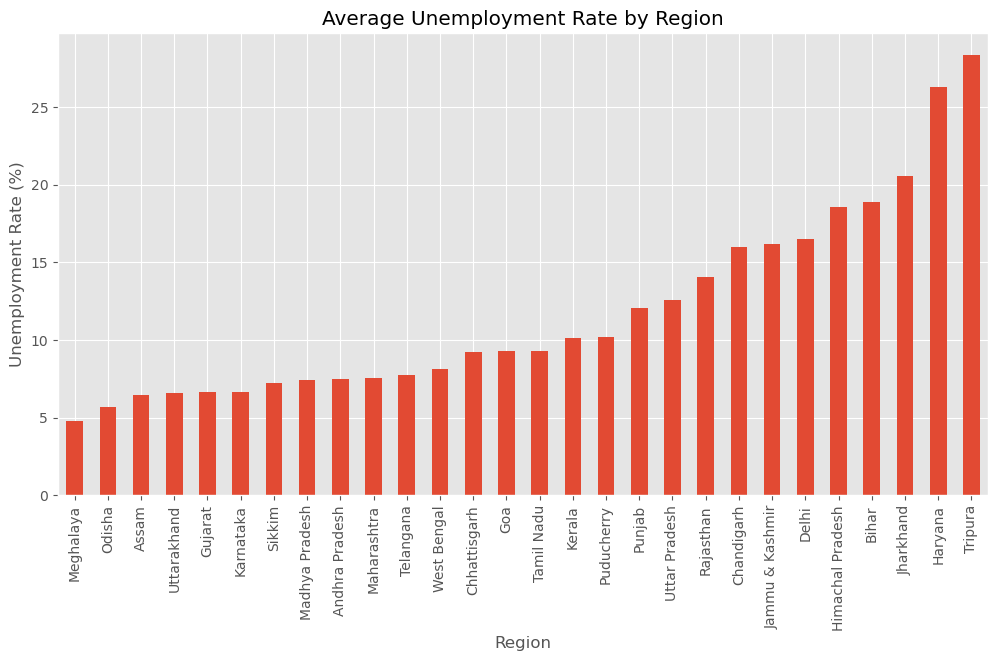

In [19]:
plt.figure(figsize=(12,6))
region_avg.plot(kind="bar")
plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [20]:
df["Month"] = df["Date"].dt.month_name()

In [21]:
month_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

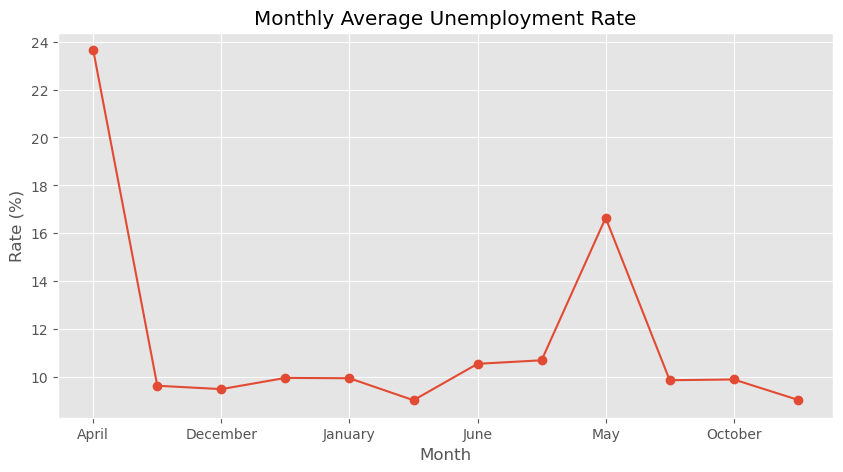

In [22]:
plt.figure(figsize=(10,5))
month_avg.plot(marker="o")
plt.title("Monthly Average Unemployment Rate")
plt.ylabel("Rate (%)")
plt.show()

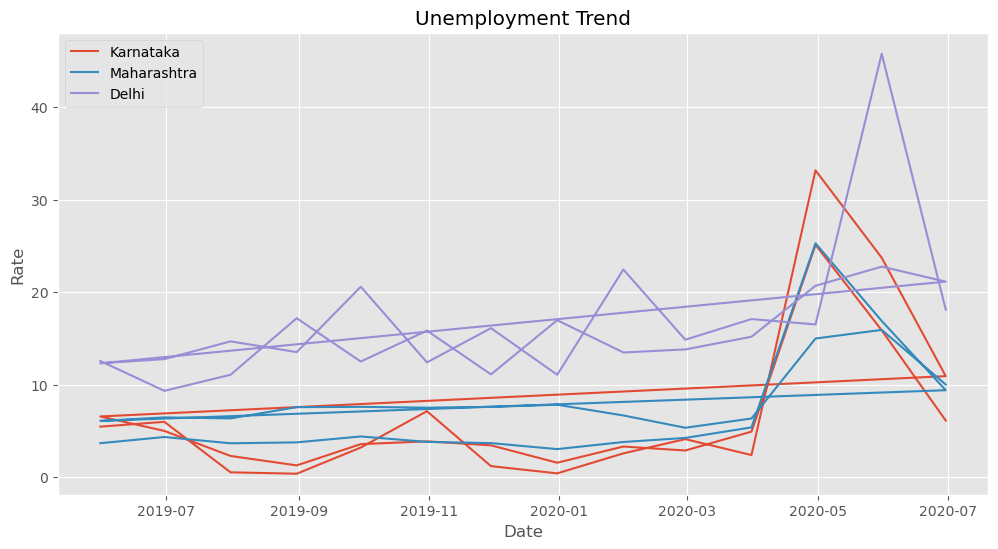

In [23]:
states = ["Karnataka","Maharashtra","Delhi"]

plt.figure(figsize=(12,6))

for state in states:
    temp = df[df["Region"]==state]
    plt.plot(temp["Date"],
             temp["Estimated Unemployment Rate (%)"],
             label=state)

plt.legend()
plt.title("Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()

In [24]:
top10 = region_avg.sort_values(ascending=False).head(10)

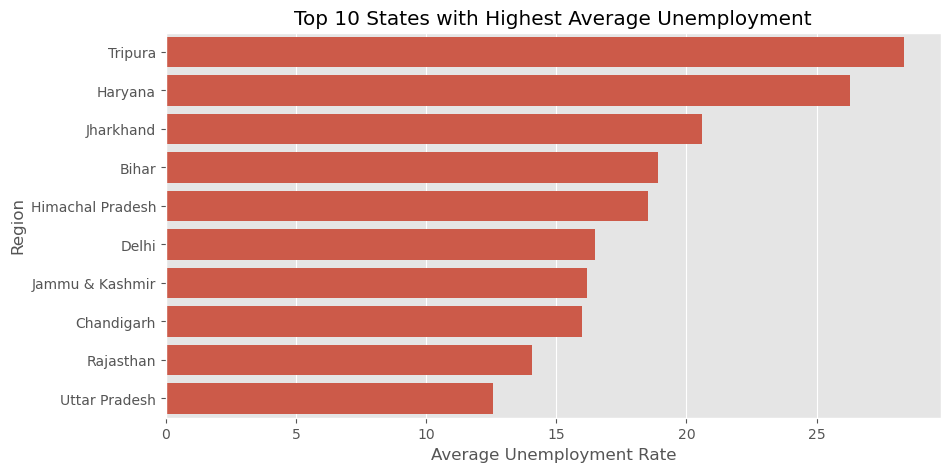

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(x=top10.values,
            y=top10.index)

plt.title("Top 10 States with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate")
plt.show()

In [26]:
corr = df[[
"Estimated Unemployment Rate (%)",
"Estimated Employed",
"Estimated Labour Participation Rate (%)"
]].corr()

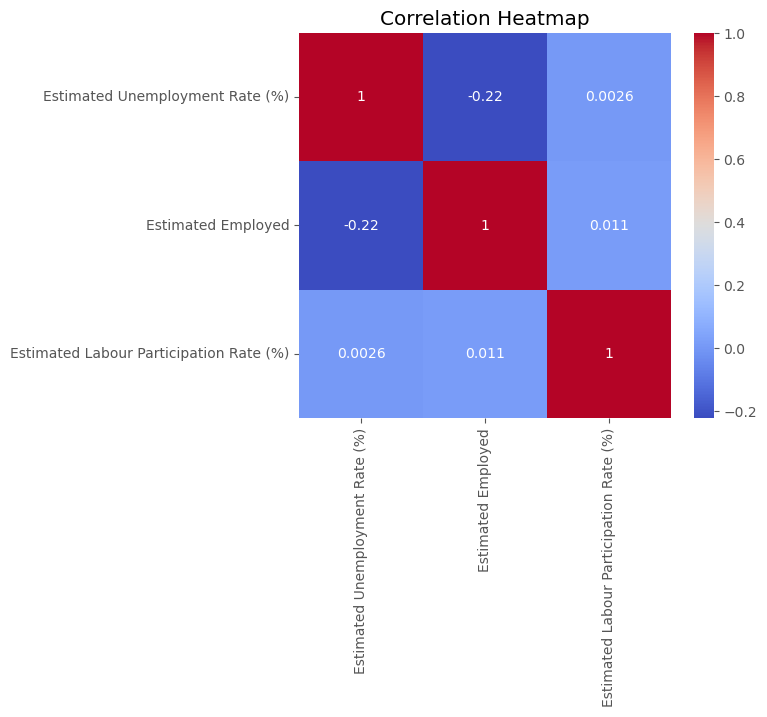

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [28]:
pre = df[df["Date"] < "2020-03-25"]

post = df[df["Date"] >= "2020-03-25"]

In [29]:
print("Pre COVID")

print(pre["Estimated Unemployment Rate (%)"].mean())

print("Post COVID")

print(post["Estimated Unemployment Rate (%)"].mean())

Pre COVID
9.509533582089553
Post COVID
17.774362745098042


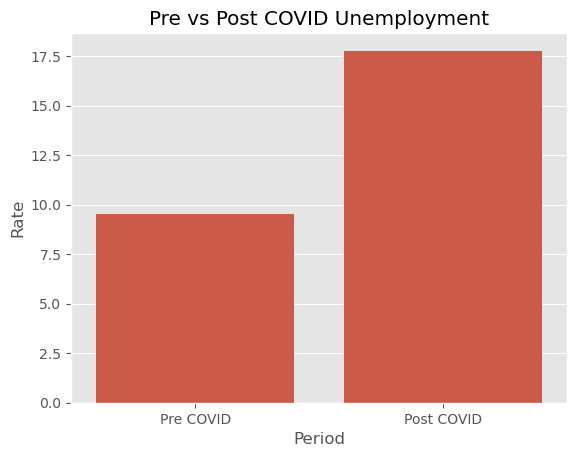

In [30]:
comparison = pd.DataFrame({
    "Period":["Pre COVID","Post COVID"],
    "Rate":[
        pre["Estimated Unemployment Rate (%)"].mean(),
        post["Estimated Unemployment Rate (%)"].mean()
    ]
})

sns.barplot(data=comparison,
            x="Period",
            y="Rate")

plt.title("Pre vs Post COVID Unemployment")
plt.show()